<a href="https://colab.research.google.com/github/kelll123/KELOMPOK-6-PROBABILITAS-STATISTIKA/blob/main/Kelompok6_Prob.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("3TID_Kelompok6_SurveiRumah.xlsx")

print(df.head())

                                                 url  price_in_rp  \
0  https://www.rumah123.com/properti/bekasi/hos11...   2990000000   
1  https://www.rumah123.com/properti/bekasi/hos10...   1270000000   
2  https://www.rumah123.com/properti/bekasi/hos10...   1950000000   
3  https://www.rumah123.com/properti/bekasi/hos10...   3300000000   
4  https://www.rumah123.com/properti/bekasi/hos10...   4500000000   

                                               title  \
0  Rumah cantik Sumarecon Bekasi Lingkungan asri,...   
1          Rumah Kekinian, Magenta Summarecon Bekasi   
2  Rumah Cantik 2 Lantai Cluster Bluebell Summare...   
3  Rumah Mewah 2Lantai L10x18 C di Cluster VERNON...   
4  Rumah Hoek di Cluster Maple Summarecon Bekasi,...   

                     address           district    city       lat        long  \
0  Summarecon Bekasi, Bekasi  Summarecon Bekasi  Bekasi -6.223945  106.986275   
1  Summarecon Bekasi, Bekasi  Summarecon Bekasi  Bekasi -6.223945  106.986275   
2  Su

In [6]:
print("Jumlah data:", df.shape)

print("\nNama kolom:")
print(df.columns)

print("\nInformasi dataset:")
df.info()

Jumlah data: (3553, 27)

Nama kolom:
Index(['url', 'price_in_rp', 'title', 'address', 'district', 'city', 'lat',
       'long', 'facilities', 'property_type', 'ads_id', 'bedrooms',
       'bathrooms', 'land_size_m2', 'building_size_m2', 'carports',
       'certificate', 'electricity', 'maid_bedrooms', 'maid_bathrooms',
       'floors', 'building_age', 'year_built', 'property_condition',
       'building_orientation', 'garages', 'furnishing'],
      dtype='object')

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3553 entries, 0 to 3552
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   3553 non-null   object 
 1   price_in_rp           3553 non-null   int64  
 2   title                 3553 non-null   object 
 3   address               3553 non-null   object 
 4   district              3553 non-null   object 
 5   city                  3553 non-null   obje

In [7]:
missing = df.isnull().sum()

print("Jumlah data kosong:")
print(missing[missing > 0])

Jumlah data kosong:
property_type              1
ads_id                     4
bedrooms                  34
bathrooms                 29
land_size_m2               2
building_size_m2           2
certificate              141
floors                     6
building_age            1445
year_built              1445
property_condition       246
building_orientation    1647
furnishing               387
dtype: int64


In [8]:
print("Jumlah data duplikat:")
print(df.duplicated().sum())

Jumlah data duplikat:
0


In [9]:
harga = df["price_in_rp"]

print("Harga minimum :", harga.min())
print("Harga maksimum:", harga.max())
print("Harga rata-rata:", harga.mean())
print("Harga median  :", harga.median())
print("Q1            :", harga.quantile(0.25))
print("Q3            :", harga.quantile(0.75))

Harga minimum : 42000000
Harga maksimum: 580000000000
Harga rata-rata: 4191684773.4309034
Harga median  : 1500000000.0
Q1            : 800000000.0
Q3            : 3590000000.0


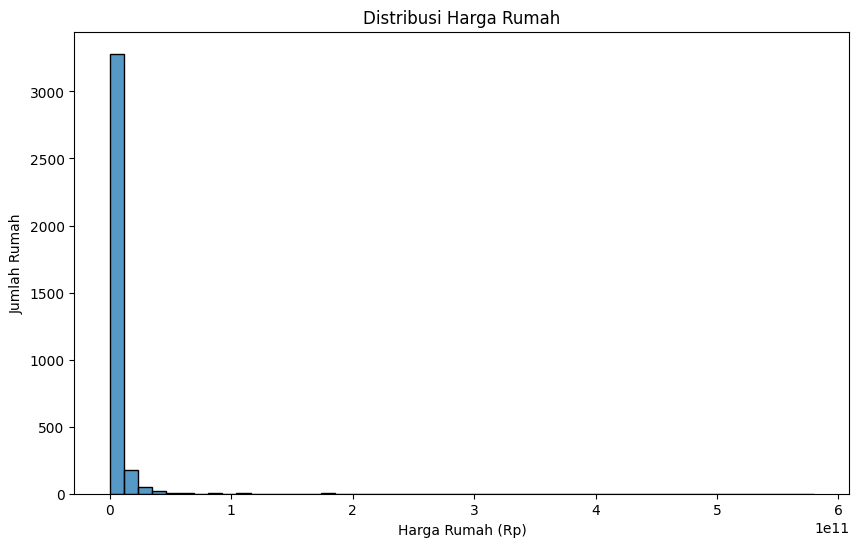

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="price_in_rp",
    bins=50
)

plt.title("Distribusi Harga Rumah")
plt.xlabel("Harga Rumah (Rp)")
plt.ylabel("Jumlah Rumah")

plt.show()

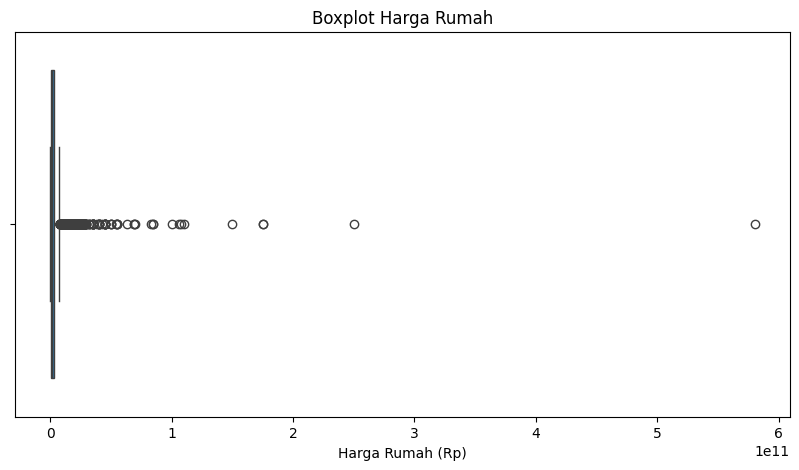

In [11]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["price_in_rp"]
)

plt.title("Boxplot Harga Rumah")
plt.xlabel("Harga Rumah (Rp)")

plt.show()

In [12]:
median_kota = (
    df.groupby("city")["price_in_rp"]
    .median()
    .sort_values(ascending=False)
)

print(median_kota)

city
Jakarta Utara      1.000000e+10
Jakarta Selatan    8.400000e+09
Jakarta Pusat      4.800000e+09
Jakarta Barat      3.200000e+09
Tangerang          2.390000e+09
Jakarta Timur      1.400000e+09
Bogor              1.150000e+09
Depok              9.950000e+08
Bekasi             9.700000e+08
Name: price_in_rp, dtype: float64


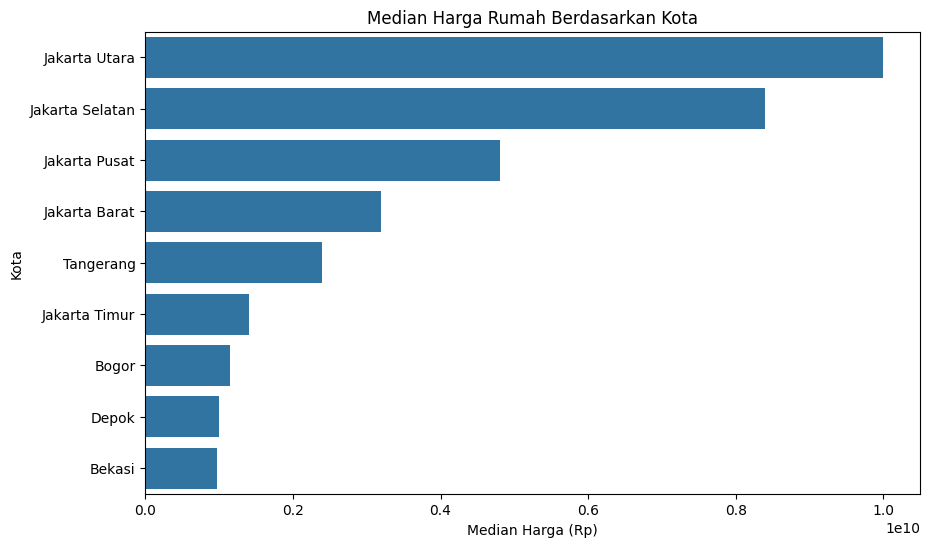

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=median_kota.values,
    y=median_kota.index
)

plt.title("Median Harga Rumah Berdasarkan Kota")
plt.xlabel("Median Harga (Rp)")
plt.ylabel("Kota")

plt.show()

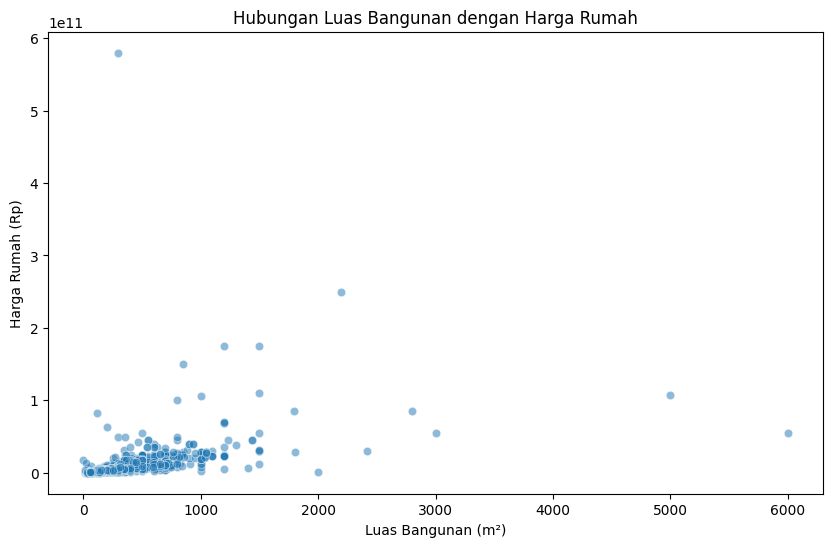

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="building_size_m2",
    y="price_in_rp",
    alpha=0.5
)

plt.title("Hubungan Luas Bangunan dengan Harga Rumah")
plt.xlabel("Luas Bangunan (m²)")
plt.ylabel("Harga Rumah (Rp)")

plt.show()

In [15]:
korelasi_bangunan = df[
    ["building_size_m2", "price_in_rp"]
].corr()

print(korelasi_bangunan)

                  building_size_m2  price_in_rp
building_size_m2          1.000000     0.488744
price_in_rp               0.488744     1.000000


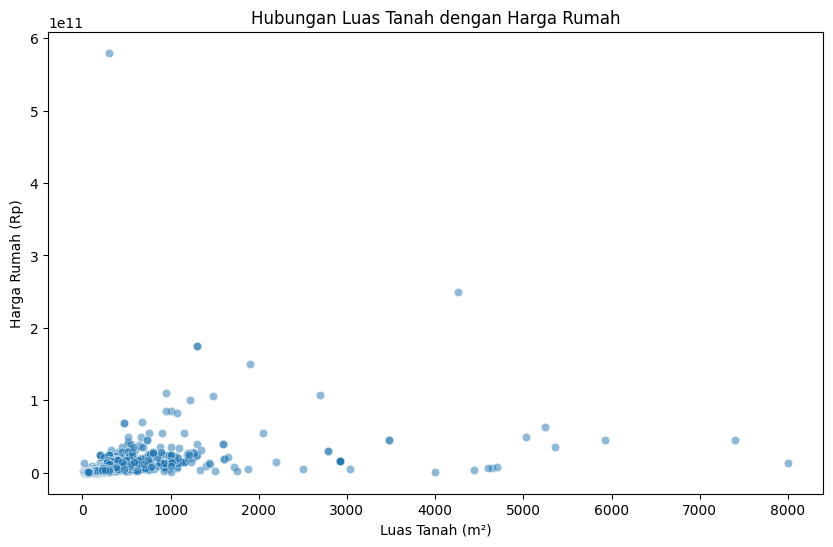

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="land_size_m2",
    y="price_in_rp",
    alpha=0.5
)

plt.title("Hubungan Luas Tanah dengan Harga Rumah")
plt.xlabel("Luas Tanah (m²)")
plt.ylabel("Harga Rumah (Rp)")

plt.show()

In [17]:
korelasi_tanah = df[
    ["land_size_m2", "price_in_rp"]
].corr()

print(korelasi_tanah)

              land_size_m2  price_in_rp
land_size_m2      1.000000     0.371807
price_in_rp       0.371807     1.000000


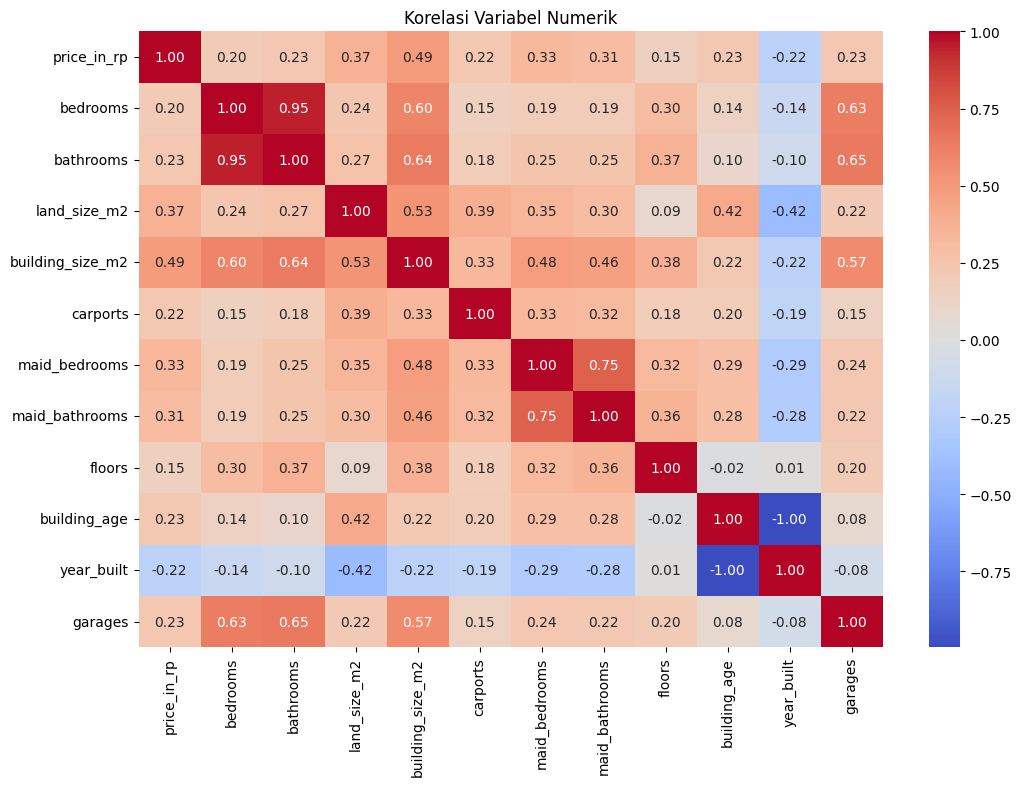

In [18]:
kolom_numerik = [
    "price_in_rp",
    "bedrooms",
    "bathrooms",
    "land_size_m2",
    "building_size_m2",
    "carports",
    "maid_bedrooms",
    "maid_bathrooms",
    "floors",
    "building_age",
    "year_built",
    "garages"
]

corr = df[kolom_numerik].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Korelasi Variabel Numerik")
plt.show()

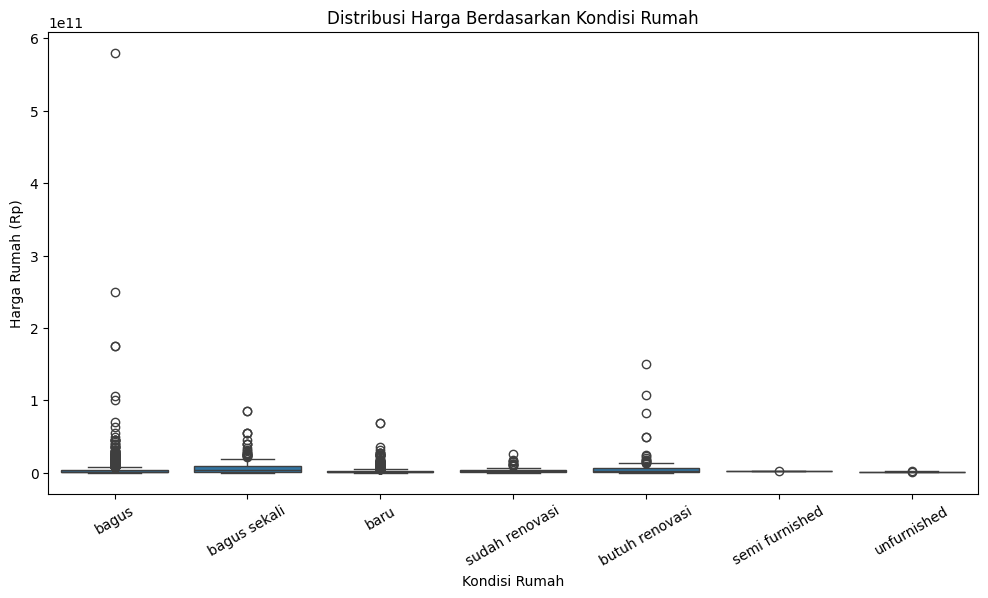

In [19]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="property_condition",
    y="price_in_rp"
)

plt.title("Distribusi Harga Berdasarkan Kondisi Rumah")
plt.xlabel("Kondisi Rumah")
plt.ylabel("Harga Rumah (Rp)")

plt.xticks(rotation=30)

plt.show()

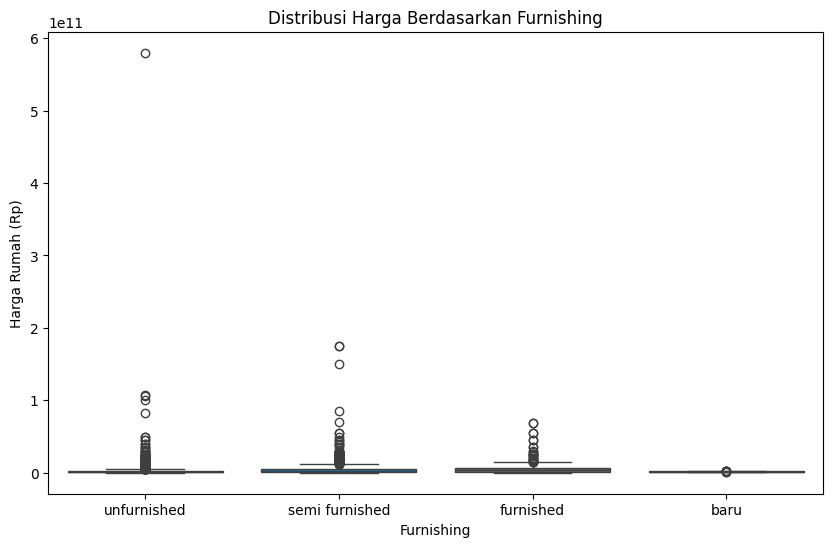

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="furnishing",
    y="price_in_rp"
)

plt.title("Distribusi Harga Berdasarkan Furnishing")
plt.xlabel("Furnishing")
plt.ylabel("Harga Rumah (Rp)")

plt.show()

In [21]:
def kategori_harga(harga):
    if harga < 1_000_000_000:
        return "Di bawah 1 Miliar"
    elif harga < 5_000_000_000:
        return "1 - 5 Miliar"
    else:
        return "Di atas 5 Miliar"

df["kategori_harga"] = df["price_in_rp"].apply(kategori_harga)

print(df["kategori_harga"].value_counts())

print("\nPersentase:")
print(
    df["kategori_harga"]
    .value_counts(normalize=True) * 100
)

kategori_harga
1 - 5 Miliar         1741
Di bawah 1 Miliar    1187
Di atas 5 Miliar      625
Name: count, dtype: int64

Persentase:
kategori_harga
1 - 5 Miliar         49.000844
Di bawah 1 Miliar    33.408387
Di atas 5 Miliar     17.590768
Name: proportion, dtype: float64


In [22]:
batas_harga = 5_000_000_000

jumlah_diatas = (
    df["price_in_rp"] > batas_harga
).sum()

jumlah_data = len(df)

probabilitas = jumlah_diatas / jumlah_data

print("Jumlah rumah:", jumlah_diatas)
print("Total data:", jumlah_data)
print("Probabilitas:", probabilitas)
print("Persentase:", probabilitas * 100, "%")

Jumlah rumah: 596
Total data: 3553
Probabilitas: 0.1677455671263721
Persentase: 16.77455671263721 %


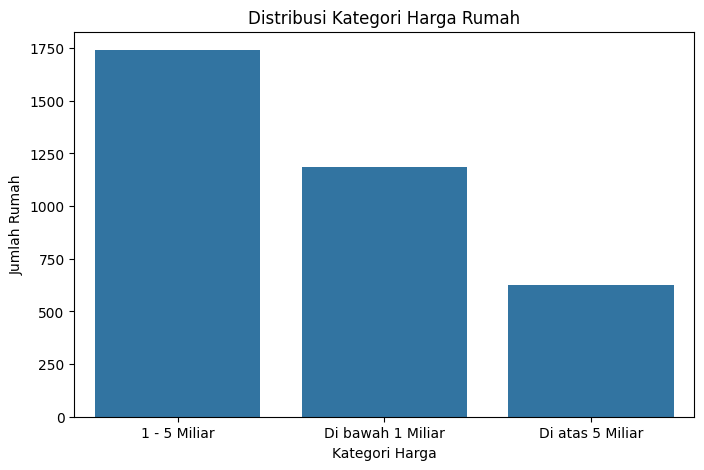

In [23]:
kategori = df["kategori_harga"].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=kategori.index,
    y=kategori.values
)

plt.title("Distribusi Kategori Harga Rumah")
plt.xlabel("Kategori Harga")
plt.ylabel("Jumlah Rumah")

plt.show()